In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
import os
print(os.listdir('/content'))

['.config', 'drive', 'sample_data']


In [27]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'recycle and waste project']


In [28]:
DATASET_PATH = '/content/drive/MyDrive/recycle and waste project'

In [29]:
for root, dirs, files in os.walk(DATASET_PATH):

    print("\n📂", root)
    print("Folders:", dirs)

    if len(files) > 0:
        print("Sample Images:", files[:3])

    if root.count(os.sep) > 5:
        break


📂 /content/drive/MyDrive/recycle and waste project
Folders: ['images']

📂 /content/drive/MyDrive/recycle and waste project/images
Folders: ['tea_bags', 'styrofoam_food_containers', 'steel_food_cans', 'styrofoam_cups', 'plastic_water_bottles', 'shoes', 'plastic_detergent_bottles', 'plastic_trash_bags', 'plastic_soda_bottles', 'plastic_shopping_bags', 'plastic_straws', 'plastic_food_containers', 'office_paper', 'paper_cups', 'plastic_cup_lids', 'newspaper', 'magazines', 'glass_food_jars', 'food_waste', 'glass_beverage_bottles', 'glass_cosmetic_containers', 'disposable_plastic_cutlery', 'eggshells', 'coffee_grounds', 'clothing', 'cardboard_packaging', 'aluminum_food_cans', 'cardboard_boxes', 'aluminum_soda_cans', 'aerosol_cans']

📂 /content/drive/MyDrive/recycle and waste project/images/tea_bags
Folders: ['default', 'real_world']


In [30]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

DATASET_PATH = '/content/drive/MyDrive/recycle and waste project/images'

IMG_SIZE = 128
BATCH_SIZE = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True
)

val_generator = datagen.flow_from_directory(

    DATASET_PATH,

    target_size=(IMG_SIZE, IMG_SIZE),

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("✅ Dataset Loaded Successfully")

Found 12000 images belonging to 30 classes.
Found 3000 images belonging to 30 classes.
✅ Dataset Loaded Successfully


In [31]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, Model

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

inputs = layers.Input(shape=(128,128,3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)

outputs = layers.Dense(
    train_generator.num_classes,
    activation='softmax'
)(x)

model = Model(inputs, outputs)

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [32]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=3
)

Epoch 1/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 276s 361ms/step - accuracy: 0.6549 - loss: 1.1932 - val_accuracy: 0.7610 - val_loss: 0.7404
Epoch 2/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 272s 363ms/step - accuracy: 0.8123 - loss: 0.5942 - val_accuracy: 0.7937 - val_loss: 0.6482
Epoch 3/3
750/750 ━━━━━━━━━━━━━━━━━━━━ 278s 370ms/step - accuracy: 0.8753 - loss: 0.3839 - val_accuracy: 0.8240 - val_loss: 0.5521


In [33]:
loss, accuracy = model.evaluate(val_generator)

print(f"Validation Accuracy: {accuracy*100:.2f}%")

188/188 ━━━━━━━━━━━━━━━━━━━━ 53s 284ms/step - accuracy: 0.8240 - loss: 0.5521
Validation Accuracy: 82.40%


In [34]:
model.save("waste_classification_model.h5")

print("✅ Model Saved")

✅ Model Saved


In [35]:
from google.colab import files

files.download("waste_classification_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [36]:
import json

class_names = list(train_generator.class_indices.keys())

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

files.download("class_names.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [37]:
from google.colab import files

uploaded = files.upload()

Saving Image_1.png to Image_1.png


In [38]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(128,128))

img_array = image.img_to_array(img)

img_array = np.expand_dims(img_array, axis=0)

img_array = img_array / 255.0

prediction = model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

print("Predicted Waste Type:", predicted_class)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Predicted Waste Type: aerosol_cans


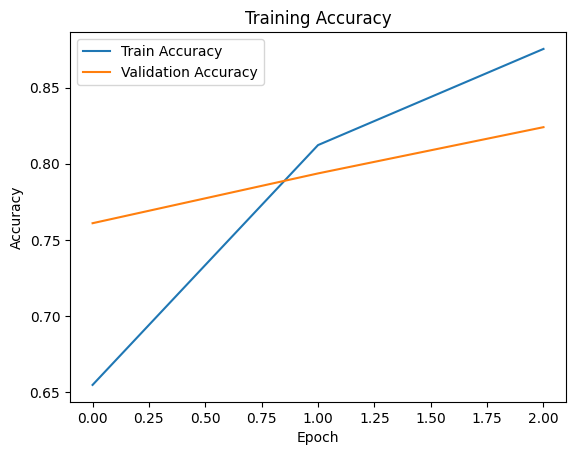

In [39]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.title('Training Accuracy')

plt.legend()

plt.show()

188/188 ━━━━━━━━━━━━━━━━━━━━ 75s 364ms/step


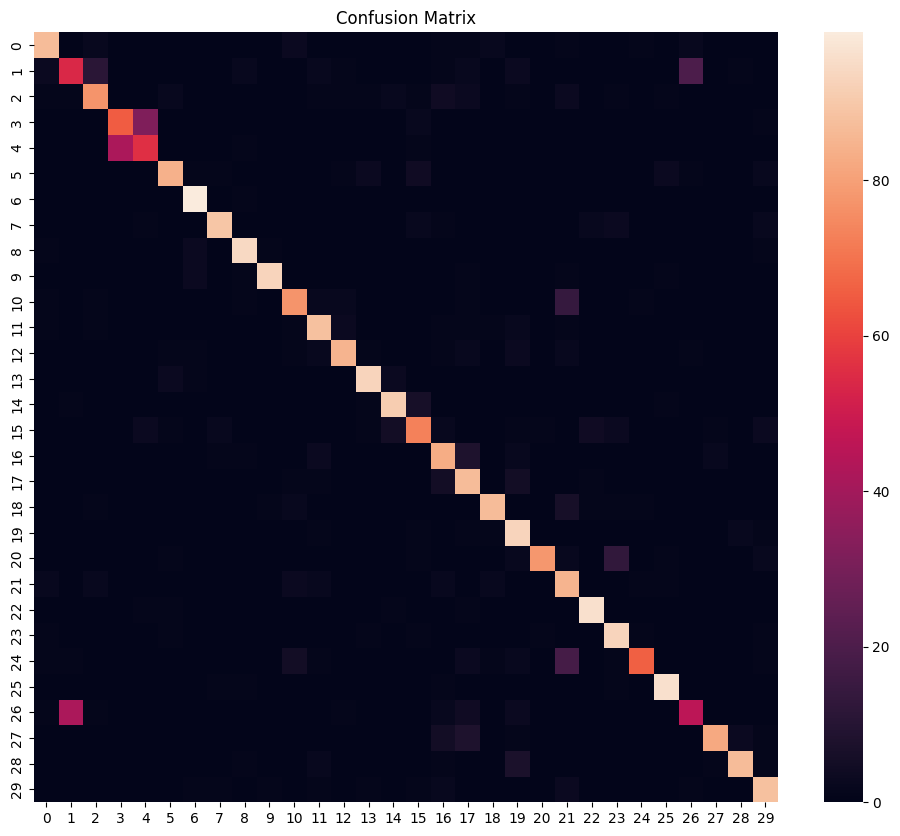

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

Y_pred = model.predict(val_generator)

y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(cm, annot=False)

plt.title("Confusion Matrix")

plt.show()

In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    val_generator.classes,
    y_pred,
    target_names=class_names
))

                            precision    recall  f1-score   support

              aerosol_cans       0.88      0.87      0.87       100
        aluminum_food_cans       0.55      0.54      0.54       100
        aluminum_soda_cans       0.80      0.77      0.79       100
           cardboard_boxes       0.61      0.65      0.63       100
       cardboard_packaging       0.60      0.56      0.58       100
                  clothing       0.89      0.84      0.87       100
            coffee_grounds       0.91      0.99      0.95       100
disposable_plastic_cutlery       0.94      0.89      0.91       100
                 eggshells       0.91      0.94      0.93       100
                food_waste       0.97      0.93      0.95       100
    glass_beverage_bottles       0.83      0.77      0.80       100
 glass_cosmetic_containers       0.83      0.88      0.85       100
           glass_food_jars       0.90      0.85      0.88       100
                 magazines       0.91      0.93